In [844]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [845]:
df=pd.read_csv("bmi.csv")

In [846]:
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [847]:
df.tail()

,Gender,Height,Weight,Index
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5
499,Male,173,131,5


In [848]:
df.shape

(500, 4)

In [849]:
df.isnull().sum()

Gender    0
Height    0
Weight    0
Index     0
dtype: int64

In [850]:
df.info

<bound method DataFrame.info of      Gender  Height  Weight  Index
0      Male     174      96      4
1      Male     189      87      2
2    Female     185     110      4
3    Female     195     104      3
4      Male     149      61      3
..      ...     ...     ...    ...
495  Female     150     153      5
496  Female     184     121      4
497  Female     141     136      5
498    Male     150      95      5
499    Male     173     131      5

[500 rows x 4 columns]>

In [851]:
df.dtypes

Gender      str
Height    int64
Weight    int64
Index     int64
dtype: object

In [852]:
from sklearn.preprocessing import LabelEncoder

In [853]:
le=LabelEncoder()

In [854]:
df["Gender"]=le.fit_transform(df["Gender"])

In [855]:
x=df.drop(columns="Index")
y=df["Index"]

In [856]:
from sklearn.model_selection import train_test_split

In [857]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=1)

In [858]:
from sklearn.preprocessing import MinMaxScaler

In [859]:
scaler = MinMaxScaler()

In [860]:
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[ 1.,199.,160.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[ 0.,140., 50.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[ 1., 59.,110.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Gender','Height','Weight']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[ 0. ,-2.37,-0.45]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,375


In [861]:
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [862]:
from sklearn.neighbors import KNeighborsClassifier

In [863]:
model=KNeighborsClassifier(n_neighbors=7)

In [864]:
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](6,)","[0,1,2,3,4,5]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [865]:
model.predict(x_test)

array([5, 3, 4, 2, 5, 4, 5, 1, 4, 5, 5, 3, 5, 4, 4, 5, 2, 5, 5, 3, 4, 4,
       5, 0, 5, 4, 5, 4, 4, 3, 3, 5, 2, 5, 4, 5, 2, 2, 4, 4, 3, 2, 5, 4,
       5, 3, 5, 5, 1, 5, 4, 0, 3, 2, 5, 1, 2, 5, 5, 2, 2, 1, 5, 5, 2, 5,
       2, 5, 4, 3, 4, 4, 5, 5, 5, 5, 5, 2, 4, 5, 5, 5, 2, 4, 2, 5, 4, 5,
       5, 5, 3, 5, 2, 5, 5, 4, 4, 3, 5, 3, 2, 1, 5, 3, 5, 4, 3, 5, 4, 5,
       4, 2, 4, 4, 4, 3, 5, 5, 4, 5, 4, 5, 4, 4, 5])

In [866]:
print(y_test)

304    5
340    3
47     4
67     2
479    5
      ..
469    3
41     5
159    4
286    4
132    5
Name: Index, Length: 125, dtype: int64


In [867]:
from sklearn.metrics import confusion_matrix

In [868]:
y_pred=model.predict(x_test)

In [869]:
cm=confusion_matrix(y_test,y_pred)

In [870]:
from sklearn.metrics import ConfusionMatrixDisplay

In [871]:
cmd=ConfusionMatrixDisplay(cm)

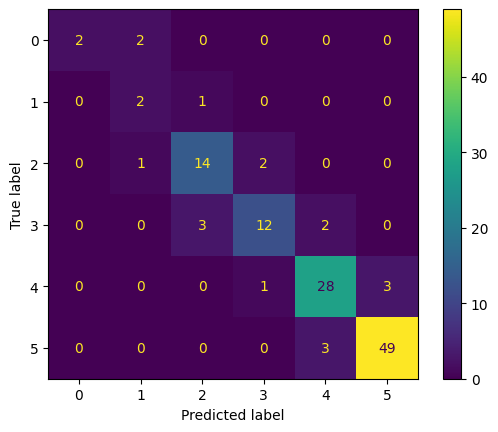

In [872]:
cmd.plot()

In [873]:
from sklearn.metrics import accuracy_score

In [874]:
acc=accuracy_score(y_test,y_pred)

In [875]:
acc

0.856